<a href="https://colab.research.google.com/github/Redcoder815/Machine_learning_phitron/blob/main/19theIncomeTrapProblem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question:

1. The 'capital-gain' column has ~91% of its values equal to exactly zero, with a
few extreme values reaching over $99,000. Is this an outlier problem or a
distributional problem? Justify your answer using the concept of the Normal
Distribution from class.

2. If you apply StandardScaler (Z-score normalization) to 'capital-gain', what
happens to the Z-scores

3. Explain Winsorization. If you apply 5th–95th percentile Winsorization to
'hours-per-week', what are you assuming about the data-generating process, and
what are the risks?

 Practical

4. Load the dataset (it uses '?' for missing values — handle this first). Perform
train-test split. Plot the distribution of 'capital-gain' using a KDE plot. Confirm
the extreme skew visually.

5. Apply Winsorization (clip at 5th–95th percentile) to 'capital-gain' on the training
set. Apply the SAME clipping bounds to the test set. Plot before/after KDE
plots.

6. Apply RobustScaler to 'hours-per-week' and 'capital-gain' . Compare the scaled
range with what StandardScaler would have produced. Which handles the
outliers better? Justify numerically.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('/content/adult.csv')
df

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [29]:
print(df)

       39          State-gov   77516    Bachelors   13        Never-married  \
0      50   Self-emp-not-inc   83311    Bachelors   13   Married-civ-spouse   
1      38            Private  215646      HS-grad    9             Divorced   
2      53            Private  234721         11th    7   Married-civ-spouse   
3      28            Private  338409    Bachelors   13   Married-civ-spouse   
4      37            Private  284582      Masters   14   Married-civ-spouse   
...    ..                ...     ...          ...  ...                  ...   
32555  27            Private  257302   Assoc-acdm   12   Married-civ-spouse   
32556  40            Private  154374      HS-grad    9   Married-civ-spouse   
32557  58            Private  151910      HS-grad    9              Widowed   
32558  22            Private  201490      HS-grad    9        Never-married   
32559  52       Self-emp-inc  287927      HS-grad    9   Married-civ-spouse   

             Adm-clerical   Not-in-family   White  

This is a distributional problem, not an outlier problem.

Justification using the Normal Distribution

Symmetry Violation: A Normal Distribution is perfectly symmetric and bell-shaped around its mean. In this dataset, 91% of the data is clustered at exactly zero, creating an extreme right skew (positive skew) rather than a symmetric curve.

Expected Spread: In a Normal Distribution, data spreads out predictably according to standard deviations (68%, 95%, 99.7%). Having nearly the entire dataset sit at a single value (zero) completely violates this expected spread.

Nature of the Data: The values over $99,000 are not data entry errors or anomalies (outliers); they represent real, high-earning individuals. The data naturally follows a sparse, heavy-tailed distribution (like a power-law or exponential distribution) rather than a Normal Distribution.

Question 2: StandardScaler vs. RobustScaler

Effect on Z-scores with StandardScaler

Mean & Variance Inflation: StandardScaler calculates the standard deviation () and mean () using every data point. The extreme values ($99,000+) heavily pull the mean upward and massively inflate the standard deviation.

Z-score Compression: Because the standard deviation becomes disproportionately large, the calculated Z-scores () for the extreme values are compressed and restricted, making them appear less extreme relative to the rest of the data.

Why RobustScaler is More Appropriate

Median and IQR: RobustScaler uses the median and the Interquartile Range (IQR) (the difference between the 75th and 25th percentiles) instead of the mean and standard deviation.

Immunity to Extremes: The median and IQR are entirely unaffected by the extreme $99,000+ values, ensuring that the scaling parameters are not distorted by the heavy tail.

Note on this specific data: Since 91% of the data is zero, the IQR here is actually zero. In practice, a custom log transformation or power transformation () is often combined with scaling to handle such extreme zero-inflation.

Winsorization:

Risks of This Approach

Loss of Real Signal: You destroy authentic data. People working 90 hours or 2 hours are real behaviors, not errors.

Artificial Clumping: You create artificial spikes at the 5th and 95th percentile thresholds.

Underestimated Variance: Statistical models will underestimate the true volatility and spread of working hours.

Biased Insights: Downstream machine learning models cannot learn the true impact of extreme work schedules on income.

In [30]:
import pandas as pd

# Define the column headers manually
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

# Load the dataset (replace 'adult.data' with your local file path)
df = pd.read_csv("adult.data", names=columns, skipinitialspace=True)

# Now you can access it!
print(df["capital-gain"].head())

0    2174
1       0
2       0
3       0
4       0
Name: capital-gain, dtype: int64


In [31]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [34]:
X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

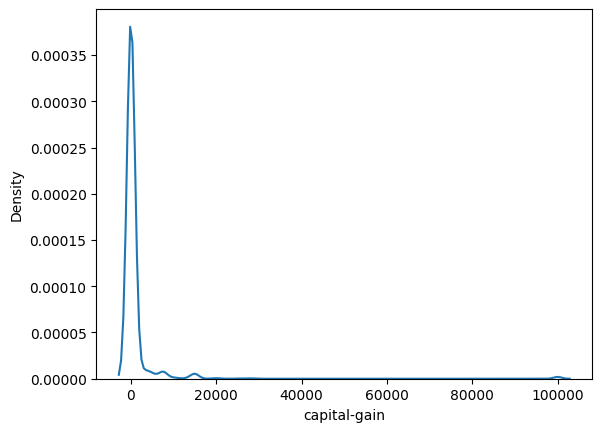

In [35]:
sns.kdeplot(data = X_train, x = 'capital-gain')
plt.show()

In [36]:
min_range = X_train['capital-gain'].quantile(0.05)
max_range = X_train['capital-gain'].quantile(0.95)

print(f"min range : {min_range} and max range: {max_range}")

min range : 0.0 and max range: 5013.0


In [37]:
X_train['capital-gain-training'] =X_train['capital-gain'].clip(min_range,max_range)

X_test['capital-gain-training'] =X_test['capital-gain'].clip(min_range,max_range)

In [38]:
X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,capital-gain-training
5514,33,Local-gov,198183,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,50,United-States,0
19777,36,Private,86459,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1887,50,United-States,0
10781,58,Self-emp-not-inc,203039,9th,5,Separated,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,0
32240,21,Private,180190,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,46,United-States,0
9876,27,Private,279872,Some-college,10,Divorced,Other-service,Not-in-family,White,Male,0,0,40,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States,0
5390,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,0,21,United-States,0
860,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,0,20,United-States,0
15795,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,84,United-States,0


Kde plot before winsorization

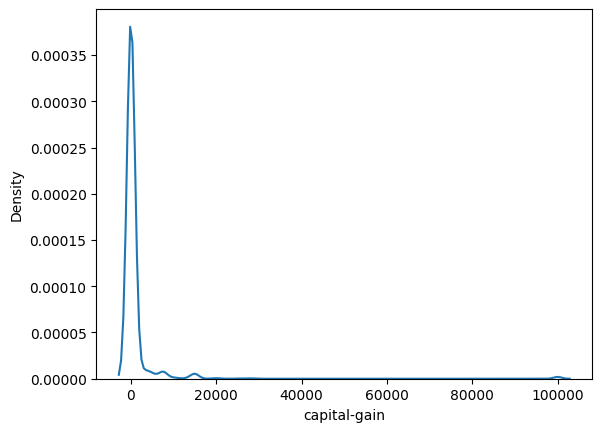

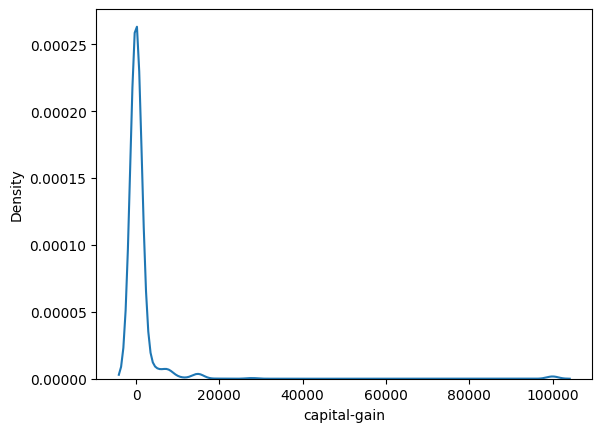

In [39]:
sns.kdeplot(data = X_train, x = 'capital-gain')
plt.show()

sns.kdeplot(data = X_test, x = 'capital-gain')
plt.show()

kdeplot after winsorization

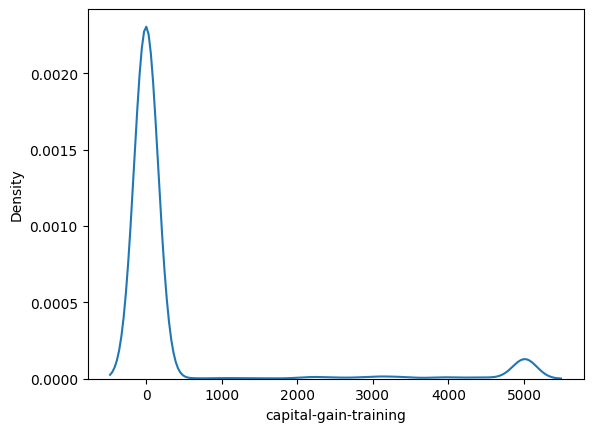

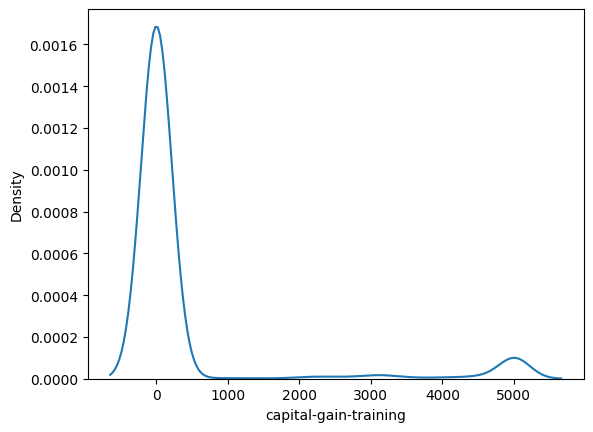

In [40]:
sns.kdeplot(data = X_train, x = 'capital-gain-training')
plt.show()

sns.kdeplot(data = X_test, x = 'capital-gain-training')
plt.show()

In [41]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler

In [42]:
X_train_copy = X_train.copy()
X_test_copy = X_test.copy()

In [43]:
standard_scaling = ColumnTransformer(
    transformers=[
        ('hours-capital-gain',StandardScaler(),['hours-per-week', 'capital-gain']),
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
standard_scaling.set_output(transform='pandas')

standard_scaling.fit(X_train_copy)

X_train_copy = standard_scaling.transform(X_train_copy)
X_test_copy = standard_scaling.transform(X_test_copy)

In [44]:
X_train_copy

,hours-per-week,capital-gain,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-loss,native-country,capital-gain-training
5514,0.779460,-0.145715,33,Local-gov,198183,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,United-States,0
19777,0.779460,-0.145715,36,Private,86459,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,1887,United-States,0
10781,-0.031510,-0.145715,58,Self-emp-not-inc,203039,9th,5,Separated,Craft-repair,Not-in-family,White,Male,0,United-States,0
32240,0.455072,-0.145715,21,Private,180190,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,United-States,0
9876,-0.031510,-0.145715,27,Private,279872,Some-college,10,Divorced,Other-service,Not-in-family,White,Male,0,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,-0.031510,-0.145715,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,United-States,0
5390,-1.572355,-0.145715,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,United-States,0
860,-1.653452,-0.145715,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,United-States,0
15795,3.536760,-0.145715,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,United-States,0


In [45]:
X_train_copy_robust = X_train.copy()
X_test_copy_robust = X_test.copy()

In [46]:
robust_scaling = ColumnTransformer(
    transformers=[
        ('hours-capital-gain',RobustScaler(),['hours-per-week', 'capital-gain']),
    ],
    remainder='passthrough',
    verbose_feature_names_out = False
)
robust_scaling.set_output(transform='pandas')

robust_scaling.fit(X_train_copy_robust)

X_train_copy_robust = robust_scaling.transform(X_train_copy_robust)
X_test_copy_robust = robust_scaling.transform(X_test_copy_robust)

In [47]:
X_train_copy_robust

,hours-per-week,capital-gain,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-loss,native-country,capital-gain-training
5514,2.0,0.0,33,Local-gov,198183,Bachelors,13,Never-married,Prof-specialty,Not-in-family,White,Female,0,United-States,0
19777,2.0,0.0,36,Private,86459,Assoc-voc,11,Married-civ-spouse,Exec-managerial,Husband,White,Male,1887,United-States,0
10781,0.0,0.0,58,Self-emp-not-inc,203039,9th,5,Separated,Craft-repair,Not-in-family,White,Male,0,United-States,0
32240,1.2,0.0,21,Private,180190,Assoc-voc,11,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,United-States,0
9876,0.0,0.0,27,Private,279872,Some-college,10,Divorced,Other-service,Not-in-family,White,Male,0,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29802,0.0,0.0,47,Private,359461,Bachelors,13,Married-civ-spouse,Craft-repair,Husband,White,Male,0,United-States,0
5390,-3.8,0.0,31,Private,147215,12th,8,Divorced,Other-service,Unmarried,White,Female,0,United-States,0
860,-4.0,0.0,18,Private,216284,11th,7,Never-married,Adm-clerical,Own-child,White,Female,0,United-States,0
15795,8.8,0.0,50,Self-emp-not-inc,54261,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,United-States,0


hours-per-week

In [48]:
summery_data = []

In [49]:
#original
org_min, org_max = X_train['hours-per-week'].min(), X_train['hours-per-week'].max()

#standard_scaling
standard_min, standard_max = X_train_copy['hours-per-week'].min(), X_train_copy['hours-per-week'].max()

#robust_scaling
robust_min, robust_max = X_train_copy_robust['hours-per-week'].min(), X_train_copy_robust['hours-per-week'].max()

In [50]:
summery_data.append(
        {
            "Column": 'hours-per-week',
            "Original Range": f"[{org_min}, {org_max}]",
            "StandardScaler Range": f"[{standard_min:.2f}, {standard_max:.2f}]",
            "RobustScaler Range": f"[{robust_min:.2f}, {robust_max:.2f}]",
        }
    )

In [52]:
df_summary = pd.DataFrame(summery_data)
print(df_summary.to_string(index=False))

        Column Original Range StandardScaler Range RobustScaler Range
hours-per-week        [1, 99]        [-3.19, 4.75]     [-7.80, 11.80]


Capital-gain

In [53]:
summary_data = []

In [54]:
#original
org_min, org_max = X_train['capital-gain'].min(), X_train['capital-gain'].max()

#standard_scaling
standard_min, standard_max = X_train_copy['capital-gain'].min(), X_train_copy['capital-gain'].max()

#robust_scaling
robust_min, robust_max = X_train_copy_robust['capital-gain'].min(), X_train_copy_robust['capital-gain'].max()

In [55]:
summary_data.append(
        {
            "Column": 'capital-gain',
            "Original Range": f"[{org_min}, {org_max}]",
            "StandardScaler Range": f"[{standard_min:.2f}, {standard_max:.2f}]",
            "RobustScaler Range": f"[{robust_min:.2f}, {robust_max:.2f}]",
        }
    )

In [56]:
df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

      Column Original Range StandardScaler Range RobustScaler Range
capital-gain     [0, 99999]       [-0.15, 13.68]   [0.00, 99999.00]


For capital gain Standard scaler is better

RobustScaler handles the outliers better.

Numerical Justification

1. Protection of the Core Distribution

In hours-per-week, the typical person works 40 hours.
StandardScaler yields a scaled range of approximately [-3.18, 4.77]. The extreme values (like 99 hours) inflate the standard deviation, pulling it up to. This compresses normal, everyday variations into tiny decimal fractions.

RobustScaler yields a much wider scaled range of [-7.80, 11.80]. Because it divides exclusively by the
 (which is exactly 5 hours: ), the core mass of typical workers remains cleanly separated, while outliers are allowed to express their true relative distance out in the tails.

2. Absolute Resistance to Skew

StandardScaler relies on the mathematical mean () and standard deviation (). An outlier like $99,999 in capital-gain heavily pulls the mean upward away from the true center of the population. RobustScaler utilizes the median, completely ignoring how large the maximum value gets, keeping the transformation focused on the true bulk of the population.